In [1]:
# 1. Environment Setup

%load_ext autoreload
%autoreload 2

import sys
import os
# Adjust path so the notebook can look "up" and find the src folder
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
# 2. Importing custom modules

from src.data_loader import load_insurance_data
from src.eda_utils import check_data_quality, calculate_loss_ratio
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# 3. Load Data and Check quality

# Path points up to the data folder from inside the notebooks folder
df = load_insurance_data('../data/MachineLearningRating_v3.txt')

# Check data shape and quality profile
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")
check_data_quality(df)

c:\Users\nemsa\KAIM Challenge Project\Insurance-Risk-Analytics\src\data_loader.py:10: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|', index_col=False)


Dataset contains 1000098 rows and 52 columns.



,DataType,MissingValues,PercentageMissing
UnderwrittenCoverID,int64,0,0.000000
PolicyID,int64,0,0.000000
TransactionMonth,datetime64[ns],0,0.000000
IsVATRegistered,bool,0,0.000000
Citizenship,object,0,0.000000
LegalType,object,0,0.000000
Title,object,0,0.000000
Language,object,0,0.000000
Bank,object,145961,14.594670
AccountType,object,40232,4.022806


In [4]:
# 4. Calculate the Loss Ratios

# 1. Overall Portfolio Loss Ratio
overall_lr_df = calculate_loss_ratio(df)
overall_lr = overall_lr_df['LossRatio'].values[0]

print(f"--- Global Portfolio Performance ---")
print(f"Overall Portfolio Loss Ratio: {overall_lr:.2%}\n")


# 2. Loss Ratio by Province
print(f"--- Loss Ratio by Province ---")
province_lr = calculate_loss_ratio(df, group_by_col='Province')
display(province_lr)

--- Global Portfolio Performance ---
Overall Portfolio Loss Ratio: 104.77%

--- Loss Ratio by Province ---


,Province,Total_Claims,Total_Premium,LossRatio
2,Gauteng,2.939415e+07,2.405377e+07,1.222018
3,KwaZulu-Natal,1.430138e+07,1.320908e+07,1.082693
8,Western Cape,1.038977e+07,9.806559e+06,1.059472
6,North West,5.920250e+06,7.490508e+06,0.790367
5,Mpumalanga,2.044675e+06,2.836292e+06,0.720897
1,Free State,3.549223e+05,5.213632e+05,0.680758
4,Limpopo,1.016477e+06,1.537324e+06,0.661199
0,Eastern Cape,1.356427e+06,2.140104e+06,0.633813
7,Northern Cape,8.949051e+04,3.165581e+05,0.282699


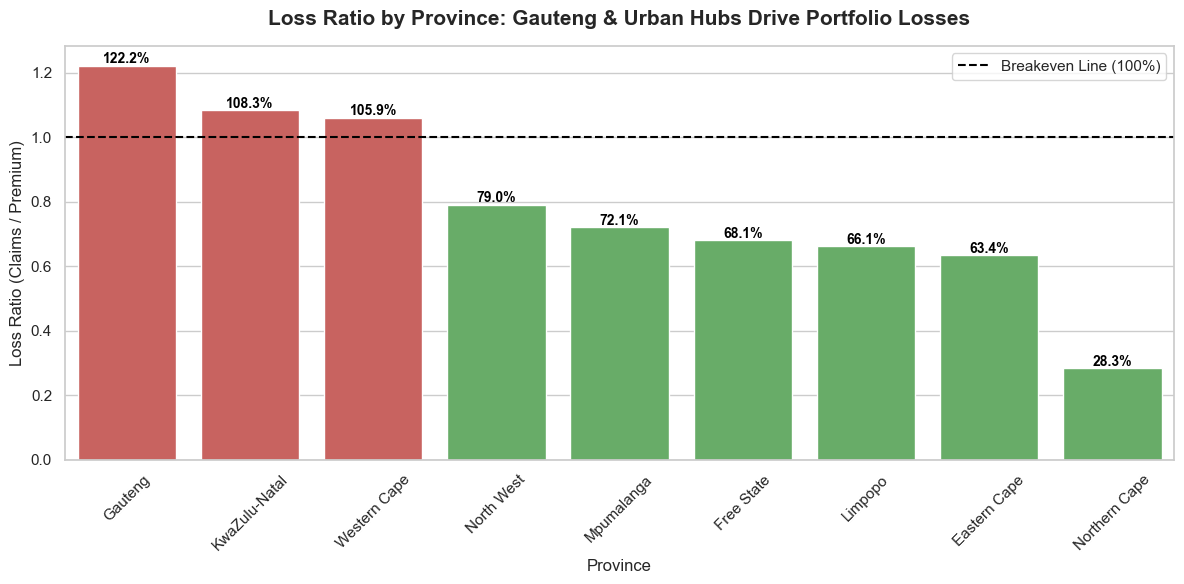

In [5]:
# 5. Creating Visualization

import seaborn as sns
import matplotlib.pyplot as plt

# Generate the data frame using the function
province_lr = calculate_loss_ratio(df, group_by_col='Province')

# Set up the plotting style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a bar chart showing the Loss Ratio across provinces
ax = sns.barplot(
    data=province_lr, 
    x='Province', 
    y='LossRatio',
    hue='Province', 
    palette= ['#d9534f' if lr > 1.0 else '#5cb85c' for lr in province_lr['LossRatio']],
    legend=False
)

# Draw a threshold line at 100% Breakeven point
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Breakeven Line (100%)')

# Clean titles and labels
plt.title('Loss Ratio by Province: Gauteng & Urban Hubs Drive Portfolio Losses', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Province', fontsize=12)
plt.ylabel('Loss Ratio (Claims / Premium)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper right')

# Display exact percentages on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.02), 
                ha='center', va='center', fontsize=10, color='black', fontweight='semibold')

plt.tight_layout()
plt.show()

In [6]:
# 1. Loss Ratio by Vehicle Type
vehicle_lr = calculate_loss_ratio(df, group_by_col='VehicleType')
print("--- Loss Ratio by Vehicle Type ---")
display(vehicle_lr)

# 2. Loss Ratio by Gender
gender_lr = calculate_loss_ratio(df, group_by_col='Gender')
print("\n--- Loss Ratio by Gender ---")
display(gender_lr)

--- Loss Ratio by Vehicle Type ---


,VehicleType,Total_Claims,Total_Premium,LossRatio
1,Heavy Commercial,7.504746e+05,4.609479e+05,1.628112
3,Medium Commercial,4.119867e+06,3.922746e+06,1.050251
4,Passenger Vehicle,5.937207e+07,5.664202e+07,1.048198
2,Light Commercial,6.045250e+04,2.604975e+05,0.232066
0,Bus,7.996535e+03,5.824474e+04,0.137292



--- Loss Ratio by Gender ---


,Gender,Total_Claims,Total_Premium,LossRatio
2,Not specified,6.271410e+07,5.920275e+07,1.059311
1,Male,1.396704e+06,1.580143e+06,0.883910
0,Female,2.502461e+05,3.044806e+05,0.821879


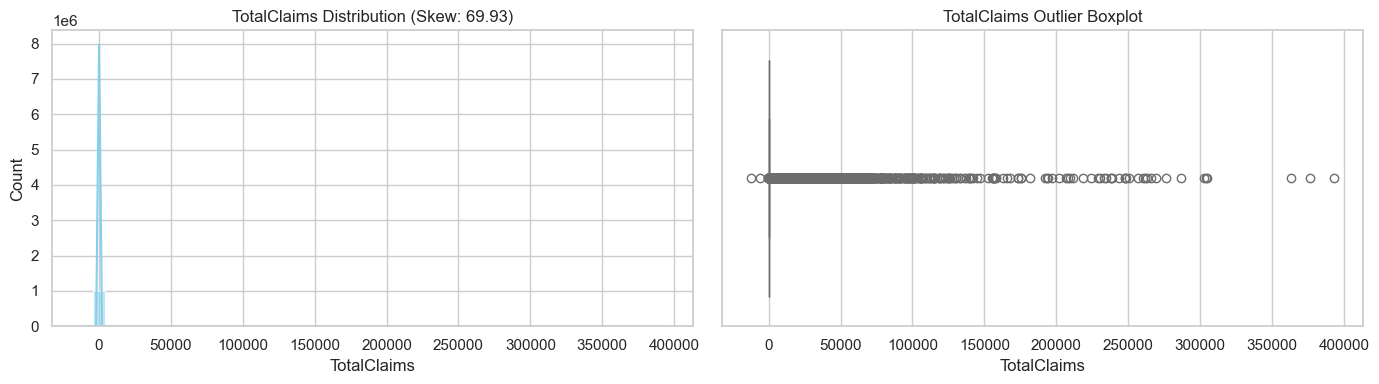

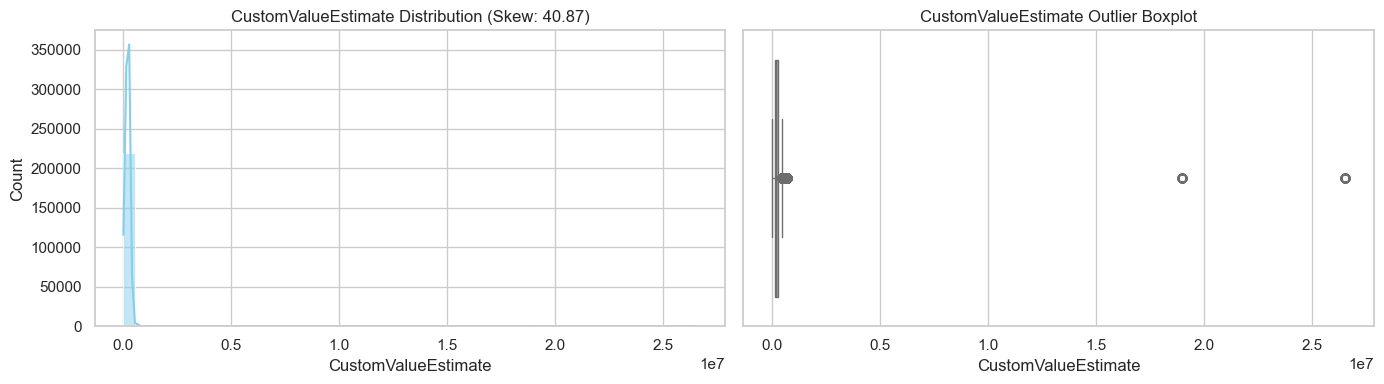

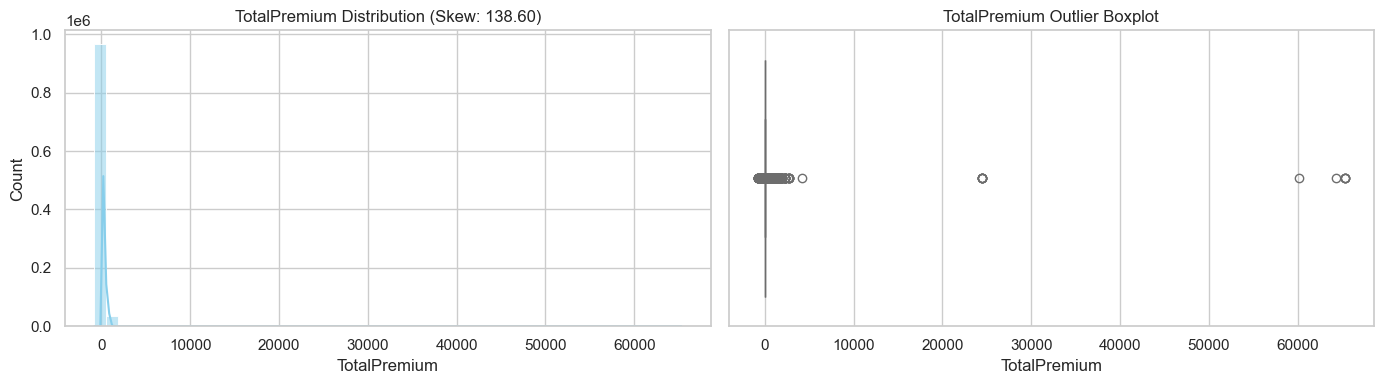

In [8]:
# Analyze distributions and outliers for key financial variables

from src.eda_utils import check_data_quality, calculate_loss_ratio, plot_financial_distributions
plot_financial_distributions(df, columns=['TotalClaims', 'CustomValueEstimate', 'TotalPremium'])

C:\Users\nemsa\AppData\Local\Temp\ipykernel_18148\1651627208.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(temporal_df['TimePeriod'], rotation=45)


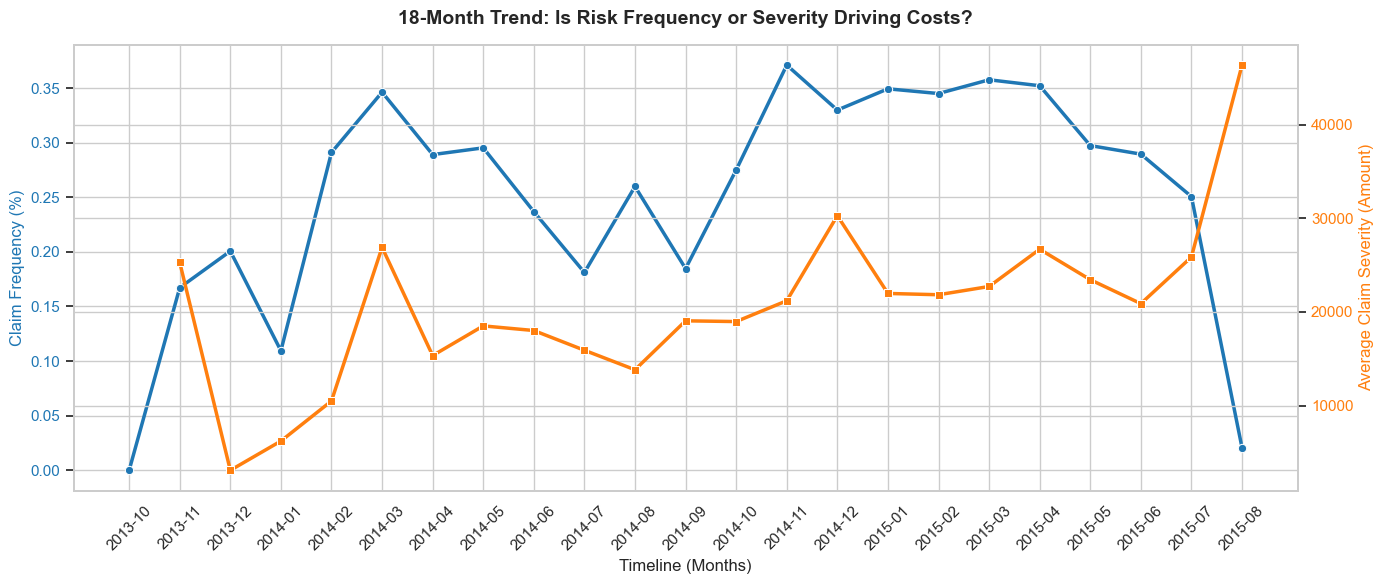

In [10]:
# Calculate trends
# Update this cell in your notebook
from src.eda_utils import check_data_quality, calculate_loss_ratio, plot_financial_distributions, calculate_temporal_trends

temporal_df = calculate_temporal_trends(df)

# Plotting the 18-Month Risk Drift
fig, ax1 = plt.subplots(figsize=(14, 6))

# Axis 1: Claim Frequency Line
color = '#1f77b4'
ax1.set_xlabel('Timeline (Months)', fontsize=12)
ax1.set_ylabel('Claim Frequency (%)', color=color, fontsize=12)
sns.lineplot(data=temporal_df, x='TimePeriod', y='Claim_Frequency_(%)', ax=ax1, color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(temporal_df['TimePeriod'], rotation=45)

# Axis 2: Share the same x-axis for Claim Severity
ax2 = ax1.twinx()  
color = '#ff7f0e'
ax2.set_ylabel('Average Claim Severity (Amount)', color=color, fontsize=12)
sns.lineplot(data=temporal_df, x='TimePeriod', y='Avg_Claim_Severity', ax=ax2, color=color, marker='s', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('18-Month Trend: Is Risk Frequency or Severity Driving Costs?', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

In [11]:
# Group by make to find total and average claims
make_analysis = df.groupby('make').agg(
    Total_Claim_Volume=('TotalClaims', 'sum'),
    Average_Claim_Cost=('TotalClaims', 'mean'),
    Policy_Count=('PolicyID', 'count')
).reset_index()

# Filter for makes with a meaningful sample size (e.g., more than 100 policies)
reliable_makes = make_analysis[make_analysis['Policy_Count'] > 100]

print("--- Top 5 Vehicle Makes Associated with HIGHEST Total Claims ---")
display(reliable_makes.sort_values(by='Total_Claim_Volume', ascending=False).head(5))

print("\n--- Top 5 Vehicle Makes Associated with LOWEST Total Claims ---")
display(reliable_makes.sort_values(by='Total_Claim_Volume', ascending=True).head(5))

--- Top 5 Vehicle Makes Associated with HIGHEST Total Claims ---


,make,Total_Claim_Volume,Average_Claim_Cost,Policy_Count
42,TOYOTA,5.174611e+07,63.626435,813280
28,MERCEDES-BENZ,2.938695e+06,70.069035,41940
44,VOLKSWAGEN,1.839180e+06,87.877091,20929
7,CMC,1.323616e+06,61.210485,21624
14,GOLDEN JOURNEY,1.246583e+06,86.197105,14462



--- Top 5 Vehicle Makes Associated with LOWEST Total Claims ---


,make,Total_Claim_Volume,Average_Claim_Cost,Policy_Count
6,CITROEN,0.0,0.0,561
4,CHERY,0.0,0.0,361
16,HONDA,0.0,0.0,130
11,FORD,0.0,0.0,242
13,GEELY,0.0,0.0,108
